# 🤖 NyayaAuth — Step 3: Model Training (Google Colab)

This notebook trains **all three models** from your research paper:

| Model | Type | Expected Accuracy |
|---|---|---|
| TF-IDF + SVM | Classical ML | ~72% (paper baseline) |
| Bi-LSTM | Deep Learning | ~85% (paper result) |
| TinyBERT | Transformer | ~94% (paper best) |

---
> **Requirements:** Run the Preprocessing notebook first so `data/processed/` exists in your Drive.
>
> **Runtime:** Go to `Runtime → Change runtime type → T4 GPU` before running.

## Cell 1 — Mount Drive + verify preprocessed data exists

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR  = "/content/drive/MyDrive/NyayaAuth"
PROC_DIR     = f"{PROJECT_DIR}/data/processed"
MODEL_DIR    = f"{PROJECT_DIR}/models"

os.makedirs(f"{MODEL_DIR}/tfidf",    exist_ok=True)
os.makedirs(f"{MODEL_DIR}/lstm",     exist_ok=True)
os.makedirs(f"{MODEL_DIR}/tinybert", exist_ok=True)

# Verify required files exist
required = ["train.csv", "val.csv", "test.csv",
            "label_encoder.pkl", "class_weights.npy"]

print("Checking preprocessed files...\n")
all_ok = True
for f in required:
    path   = f"{PROC_DIR}/{f}"
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1024 if exists else 0
    icon   = "✅" if exists else "❌"
    print(f"  {icon}  {f:30s}  {size:.1f} KB")
    if not exists:
        all_ok = False

if not all_ok:
    raise FileNotFoundError("❌ Missing files. Run the Preprocessing notebook first!")

# Check GPU
import subprocess
gpu = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                      '--format=csv,noheader'], capture_output=True, text=True)
if gpu.returncode == 0:
    print(f"\n✅ GPU detected: {gpu.stdout.strip()}")
else:
    print("\n⚠️  No GPU found. Go to Runtime → Change runtime type → T4 GPU")

print("\n✅ All checks passed. Ready to train!")

Mounted at /content/drive
Checking preprocessed files...

  ✅  train.csv                       1615.3 KB
  ✅  val.csv                         207.6 KB
  ✅  test.csv                        202.0 KB
  ✅  label_encoder.pkl               4.3 KB
  ✅  class_weights.npy               1.6 KB

✅ GPU detected: Tesla T4, 15360 MiB

✅ All checks passed. Ready to train!


## Cell 2 — Install all required packages

In [2]:
!pip install transformers==4.38.2 torch scikit-learn pandas numpy \
             joblib matplotlib seaborn tqdm datasets -q

# Verify torch sees GPU
import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device    : {DEVICE}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 127.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.2 which is incompatible.
PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
Using device    : cuda


## Cell 3 — Load data and shared config

In [3]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load splits
train_df = pd.read_csv(f"{PROC_DIR}/train.csv")
val_df   = pd.read_csv(f"{PROC_DIR}/val.csv")
test_df  = pd.read_csv(f"{PROC_DIR}/test.csv")

# Load label encoder
le = joblib.load(f"{PROC_DIR}/label_encoder.pkl")
NUM_CLASSES = len(le.classes_)

# Load class weights
class_weights = np.load(f"{PROC_DIR}/class_weights.npy")

# Use clean_text if available, else fall back to description
TEXT_COL = "clean_text" if "clean_text" in train_df.columns else "description"
print(f"Using text column: '{TEXT_COL}'")

# Fill any NaN in text columns
for df_ in [train_df, val_df, test_df]:
    df_[TEXT_COL] = df_[TEXT_COL].fillna("").astype(str)
    df_["label"]  = df_["label"].astype(int)

X_train = train_df[TEXT_COL].tolist()
y_train = train_df["label"].tolist()
X_val   = val_df[TEXT_COL].tolist()
y_val   = val_df["label"].tolist()
X_test  = test_df[TEXT_COL].tolist()
y_test  = test_df["label"].tolist()

print(f"\n📊 Dataset loaded:")
print(f"   Train : {len(X_train)} samples")
print(f"   Val   : {len(X_val)} samples")
print(f"   Test  : {len(X_test)} samples")
print(f"   IPC sections : {NUM_CLASSES}")

# Dictionary to store all results for comparison later
RESULTS = {}

Using text column: 'clean_text'

📊 Dataset loaded:
   Train : 1536 samples
   Val   : 192 samples
   Test  : 192 samples
   IPC sections : 384


---
# 🔵 MODEL 1 — TF-IDF + SVM (Baseline)
Classical machine learning baseline — matches your paper's Table 4 baseline entry.

## Cell 4 — Train TF-IDF + SVM

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report
)
from sklearn.calibration import CalibratedClassifierCV
import time

print("=" * 55)
print("  MODEL 1: TF-IDF + SVM")
print("=" * 55)

# Build pipeline
tfidf_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),      # unigrams + bigrams
        sublinear_tf=True,       # apply log normalization
        min_df=1,
        analyzer="word"
    )),
    ("clf", CalibratedClassifierCV(
        LinearSVC(
            C=1.0,
            max_iter=5000,
            class_weight="balanced"   # handles class imbalance
        ),
        cv=min(3, max(2, len(set(y_train)) // 10))
    ))
])

print("Training TF-IDF + SVM ...")
t0 = time.time()
tfidf_pipeline.fit(X_train, y_train)
train_time = time.time() - t0
print(f"Training time: {train_time:.1f}s")

# Evaluate
t1 = time.time()
y_pred_tfidf = tfidf_pipeline.predict(X_test)
infer_time   = (time.time() - t1) / len(X_test) * 1000  # ms per sample

acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
f1_tfidf  = f1_score(y_test, y_pred_tfidf, average="macro", zero_division=0)

# Top-K accuracy
y_proba_tfidf = tfidf_pipeline.predict_proba(X_test)

def topk_accuracy(y_true, y_proba, k=3):
    top_k = np.argsort(y_proba, axis=1)[:, -k:]
    return np.mean([y_true[i] in top_k[i] for i in range(len(y_true))])

topk_tfidf = topk_accuracy(np.array(y_test), y_proba_tfidf, k=3)

RESULTS["TF-IDF + SVM"] = {
    "accuracy"     : round(acc_tfidf * 100, 2),
    "macro_f1"     : round(f1_tfidf * 100, 2),
    "top3_accuracy": round(topk_tfidf * 100, 2),
    "train_time_s" : round(train_time, 1),
    "infer_ms"     : round(infer_time, 3)
}

print(f"\n✅ TF-IDF + SVM Results:")
print(f"   Accuracy     : {acc_tfidf*100:.2f}%")
print(f"   Macro F1     : {f1_tfidf*100:.2f}%")
print(f"   Top-3 Acc    : {topk_tfidf*100:.2f}%")
print(f"   Train time   : {train_time:.1f}s")
print(f"   Inference    : {infer_time:.3f} ms/sample")

# Save model
joblib.dump(tfidf_pipeline, f"{MODEL_DIR}/tfidf/tfidf_svm_model.pkl")
print(f"\n💾 Model saved → models/tfidf/tfidf_svm_model.pkl")

  MODEL 1: TF-IDF + SVM
Training TF-IDF + SVM ...
Training time: 11.1s

✅ TF-IDF + SVM Results:
   Accuracy     : 89.06%
   Macro F1     : 82.92%
   Top-3 Acc    : 97.40%
   Train time   : 11.1s
   Inference    : 0.551 ms/sample

💾 Model saved → models/tfidf/tfidf_svm_model.pkl


---
# 🟡 MODEL 2 — Bidirectional LSTM
Deep learning model with word embeddings — matches your paper's Bi-LSTM entry.

## Cell 5 — Build vocabulary and dataset for LSTM

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter

# ── Config ────────────────────────────────────────────────
MAX_LEN    = 128
VOCAB_SIZE = 20000
EMBED_DIM  = 128
HIDDEN_DIM = 256
LSTM_LAYERS= 2
DROPOUT    = 0.3
BATCH_SIZE = 32
LSTM_EPOCHS= 10
LR_LSTM    = 1e-3
PAD_IDX    = 0
UNK_IDX    = 1
# ─────────────────────────────────────────────────────────

# Build vocabulary from training data
def build_vocab(texts, max_size):
    counter = Counter()
    for t in texts:
        counter.update(str(t).lower().split())
    vocab = {"<PAD>": PAD_IDX, "<UNK>": UNK_IDX}
    for word, _ in counter.most_common(max_size - 2):
        vocab[word] = len(vocab)
    return vocab

def encode_text(text, vocab, max_len):
    tokens = str(text).lower().split()[:max_len]
    ids    = [vocab.get(t, UNK_IDX) for t in tokens]
    ids   += [PAD_IDX] * (max_len - len(ids))
    return ids

print("Building vocabulary...")
vocab = build_vocab(X_train, VOCAB_SIZE)
print(f"Vocabulary size: {len(vocab)}")

# Save vocab for inference later
joblib.dump(vocab, f"{MODEL_DIR}/lstm/vocab.pkl")

class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.encoded = [
            encode_text(t, vocab, max_len) for t in texts
        ]
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.encoded[idx], dtype=torch.long),
            torch.tensor(self.labels[idx],  dtype=torch.long)
        )

train_dataset = TextDataset(X_train, y_train, vocab, MAX_LEN)
val_dataset   = TextDataset(X_val,   y_val,   vocab, MAX_LEN)
test_dataset  = TextDataset(X_test,  y_test,  vocab, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")
print("✅ Dataset ready for LSTM")

Building vocabulary...
Vocabulary size: 1810
Train batches : 48
Val batches   : 6
Test batches  : 6
✅ Dataset ready for LSTM


## Cell 6 — Define and train Bi-LSTM model

In [8]:
import time

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_classes, num_layers, dropout, pad_idx):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.embedding  = nn.Embedding(
            vocab_size, embed_dim, padding_idx=pad_idx
        )
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers    = num_layers,
            bidirectional = True,
            batch_first   = True,
            dropout       = dropout if num_layers > 1 else 0.0
        )
        self.dropout    = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim * 2)
        self.fc         = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        # hidden shape: (num_layers * 2, batch, hidden_dim)
        # Extract last layer's forward and backward states explicitly
        forward_last  = hidden[self.num_layers * 2 - 2]   # last forward
        backward_last = hidden[self.num_layers * 2 - 1]   # last backward
        combined      = torch.cat((forward_last, backward_last), dim=1)
        combined      = self.layer_norm(combined)
        return self.fc(self.dropout(combined))


def evaluate_model(model, loader, criterion, device):
    if len(loader) == 0:
        return 0.0, 0.0
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs     = model(texts)
            loss        = criterion(outputs, labels)
            total_loss += loss.item()
            preds       = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
    avg_loss = total_loss / len(loader)
    accuracy = correct / total if total > 0 else 0.0
    return avg_loss, accuracy


# ── Fix class weights size mismatch ─────────────────────
# Ensure class_weights matches NUM_CLASSES exactly
if len(class_weights) != NUM_CLASSES:
    print(f"⚠️  class_weights size {len(class_weights)} ≠ NUM_CLASSES {NUM_CLASSES}. Recomputing...")
    counts_arr    = np.bincount(y_train, minlength=NUM_CLASSES).astype(float)
    counts_arr    = np.where(counts_arr == 0, 1, counts_arr)
    class_weights = (1.0 / counts_arr)
    class_weights = (class_weights / class_weights.sum() * NUM_CLASSES).astype(np.float32)

weights_tensor = torch.tensor(class_weights[:NUM_CLASSES], dtype=torch.float).to(DEVICE)
criterion      = nn.CrossEntropyLoss(weight=weights_tensor)

# ── Build model ──────────────────────────────────────────
lstm_model = BiLSTMClassifier(
    vocab_size  = len(vocab),
    embed_dim   = EMBED_DIM,
    hidden_dim  = HIDDEN_DIM,
    num_classes = NUM_CLASSES,
    num_layers  = LSTM_LAYERS,
    dropout     = DROPOUT,
    pad_idx     = PAD_IDX
).to(DEVICE)

total_params = sum(p.numel() for p in lstm_model.parameters())
print(f"Bi-LSTM Parameters: {total_params:,}")
print(f"Device            : {DEVICE}")

optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LR_LSTM)

# ── Fix: verbose=True removed (deprecated in PyTorch 2.x) ──
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2
)

# ── Training loop ─────────────────────────────────────────
best_val_acc   = 0.0
lstm_history   = {"train_loss": [], "val_loss": [], "val_acc": []}
BEST_LSTM_PATH = f"{MODEL_DIR}/lstm/bilstm_best.pt"

print(f"\nTraining Bi-LSTM for {LSTM_EPOCHS} epochs...")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>10} {'Val Acc':>10} {'Best':>6}")
print("-" * 50)

t0 = time.time()
for epoch in range(1, LSTM_EPOCHS + 1):
    lstm_model.train()
    total_loss = 0.0

    for texts, labels in train_loader:
        texts, labels = texts.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = lstm_model(texts)
        loss    = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    train_loss          = total_loss / max(len(train_loader), 1)
    val_loss, val_acc   = evaluate_model(lstm_model, val_loader, criterion, DEVICE)

    scheduler.step(val_acc)

    is_best = val_acc > best_val_acc
    if is_best:
        best_val_acc = val_acc
        torch.save(lstm_model.state_dict(), BEST_LSTM_PATH)

    lstm_history["train_loss"].append(train_loss)
    lstm_history["val_loss"].append(val_loss)
    lstm_history["val_acc"].append(val_acc)

    print(f"{epoch:>6} {train_loss:>12.4f} {val_loss:>10.4f} "
          f"{val_acc*100:>9.2f}%  {'★' if is_best else ' '}")

lstm_train_time = time.time() - t0
print(f"\n✅ Bi-LSTM training complete in {lstm_train_time:.1f}s")
print(f"   Best val accuracy : {best_val_acc*100:.2f}%")
print(f"   Saved             : {BEST_LSTM_PATH}")

Bi-LSTM Parameters: 2,797,184
Device            : cuda

Training Bi-LSTM for 10 epochs...
 Epoch   Train Loss   Val Loss    Val Acc   Best
--------------------------------------------------
     1       6.5350     6.2505      0.00%   
     2       5.9828     6.1600      0.52%  ★
     3       5.4585     5.9365      2.08%  ★
     4       4.8620     5.2578      4.69%  ★
     5       3.9478     4.2770     15.10%  ★
     6       2.9591     3.3604     34.38%  ★
     7       2.0802     2.6510     46.35%  ★
     8       1.4894     2.2061     51.04%  ★
     9       1.1233     1.9889     56.25%  ★
    10       0.7907     1.9564     58.85%  ★

✅ Bi-LSTM training complete in 14.8s
   Best val accuracy : 58.85%
   Saved             : /content/drive/MyDrive/NyayaAuth/models/lstm/bilstm_best.pt


## Cell 7 — Evaluate Bi-LSTM on test set

In [9]:
# Load best checkpoint
lstm_model.load_state_dict(torch.load(BEST_LSTM_PATH, map_location=DEVICE))
lstm_model.eval()

all_preds, all_labels, all_probs = [], [], []

t1 = time.time()
with torch.no_grad():
    for texts, labels in test_loader:
        texts = texts.to(DEVICE)
        out   = lstm_model(texts)
        probs = torch.softmax(out, dim=1).cpu().numpy()
        preds = out.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)

lstm_infer_time = (time.time() - t1) / len(X_test) * 1000

acc_lstm = accuracy_score(all_labels, all_preds)
f1_lstm  = f1_score(all_labels, all_preds, average="macro", zero_division=0)
topk_lstm = topk_accuracy(np.array(all_labels), np.array(all_probs), k=3)

RESULTS["Bi-LSTM"] = {
    "accuracy"     : round(acc_lstm * 100, 2),
    "macro_f1"     : round(f1_lstm * 100, 2),
    "top3_accuracy": round(topk_lstm * 100, 2),
    "train_time_s" : round(lstm_train_time, 1),
    "infer_ms"     : round(lstm_infer_time, 3)
}

print(f"✅ Bi-LSTM Test Results:")
print(f"   Accuracy     : {acc_lstm*100:.2f}%")
print(f"   Macro F1     : {f1_lstm*100:.2f}%")
print(f"   Top-3 Acc    : {topk_lstm*100:.2f}%")
print(f"   Train time   : {lstm_train_time:.1f}s")
print(f"   Inference    : {lstm_infer_time:.3f} ms/sample")
print(f"\n💾 Best model saved → models/lstm/bilstm_best.pt")

✅ Bi-LSTM Test Results:
   Accuracy     : 61.98%
   Macro F1     : 49.73%
   Top-3 Acc    : 70.83%
   Train time   : 14.8s
   Inference    : 0.570 ms/sample

💾 Best model saved → models/lstm/bilstm_best.pt


---
# 🔴 MODEL 3 — TinyBERT (Main Model)
Your paper's best model — fine-tuned transformer achieving 94% accuracy.

## Cell 8 — Load TinyBERT tokenizer and build dataset

In [10]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.utils.data import Dataset, DataLoader

# ── Config ────────────────────────────────────────────────
TINYBERT_MODEL  = "huawei-noah/TinyBERT_General_4L_312D"
BERT_MAX_LEN    = 128
BERT_BATCH_SIZE = 16
BERT_EPOCHS     = 5
LR_BERT         = 2e-5
WARMUP_RATIO    = 0.1
# ─────────────────────────────────────────────────────────

print(f"Loading TinyBERT tokenizer from: {TINYBERT_MODEL}")
tokenizer = AutoTokenizer.from_pretrained(TINYBERT_MODEL)
print("✅ Tokenizer loaded")

class BERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length    = self.max_len,
            padding       = "max_length",
            truncation    = True,
            return_tensors= "pt"
        )
        return {
            "input_ids"     : enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label"         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

bert_train = BERTDataset(X_train, y_train, tokenizer, BERT_MAX_LEN)
bert_val   = BERTDataset(X_val,   y_val,   tokenizer, BERT_MAX_LEN)
bert_test  = BERTDataset(X_test,  y_test,  tokenizer, BERT_MAX_LEN)

bert_train_loader = DataLoader(bert_train, batch_size=BERT_BATCH_SIZE, shuffle=True)
bert_val_loader   = DataLoader(bert_val,   batch_size=BERT_BATCH_SIZE)
bert_test_loader  = DataLoader(bert_test,  batch_size=BERT_BATCH_SIZE)

print(f"Train batches : {len(bert_train_loader)}")
print(f"Val batches   : {len(bert_val_loader)}")
print(f"Test batches  : {len(bert_test_loader)}")
print("✅ BERT datasets ready")

Loading TinyBERT tokenizer from: huawei-noah/TinyBERT_General_4L_312D


config.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

✅ Tokenizer loaded
Train batches : 96
Val batches   : 12
Test batches  : 12
✅ BERT datasets ready


## Cell 9 — Fine-tune TinyBERT

In [11]:
print(f"Loading TinyBERT model for {NUM_CLASSES} IPC classes...")
bert_model = AutoModelForSequenceClassification.from_pretrained(
    TINYBERT_MODEL,
    num_labels         = NUM_CLASSES,
    ignore_mismatched_sizes=True
).to(DEVICE)

total_params = sum(p.numel() for p in bert_model.parameters())
print(f"TinyBERT Parameters: {total_params:,}")

# Optimizer with weight decay (AdamW — as in your paper)
no_decay = ["bias", "LayerNorm.weight"]
param_groups = [
    {"params": [p for n, p in bert_model.named_parameters()
                if not any(nd in n for nd in no_decay)],
     "weight_decay": 0.01},
    {"params": [p for n, p in bert_model.named_parameters()
                if any(nd in n for nd in no_decay)],
     "weight_decay": 0.0}
]
optimizer_bert = torch.optim.AdamW(param_groups, lr=LR_BERT)

total_steps   = len(bert_train_loader) * BERT_EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)
scheduler_bert = get_linear_schedule_with_warmup(
    optimizer_bert,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

# Class-weighted loss
criterion_bert = nn.CrossEntropyLoss(weight=weights_tensor)

best_bert_acc   = 0.0
bert_history    = {"train_loss": [], "val_loss": [], "val_acc": []}
BEST_BERT_PATH  = f"{MODEL_DIR}/tinybert/tinybert_best.pt"
PATIENCE        = 2
no_improve      = 0

print(f"\nFine-tuning TinyBERT for {BERT_EPOCHS} epochs...")
print(f"Total steps: {total_steps} | Warmup: {warmup_steps}")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Val Loss':>10} {'Val Acc':>10} {'Best':>6}")
print("-" * 50)

t0 = time.time()
for epoch in range(1, BERT_EPOCHS + 1):
    bert_model.train()
    total_loss = 0

    for batch in bert_train_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        labels    = batch["label"].to(DEVICE)

        optimizer_bert.zero_grad()
        outputs = bert_model(
            input_ids=input_ids,
            attention_mask=attn_mask
        )
        loss = criterion_bert(outputs.logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer_bert.step()
        scheduler_bert.step()
        total_loss += loss.item()

    train_loss = total_loss / max(len(bert_train_loader), 1)

    # Validation
    bert_model.eval()
    val_loss_total, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in bert_val_loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attn_mask = batch["attention_mask"].to(DEVICE)
            labels    = batch["label"].to(DEVICE)
            outputs   = bert_model(input_ids=input_ids,
                                   attention_mask=attn_mask)
            loss      = criterion_bert(outputs.logits, labels)
            val_loss_total += loss.item()
            preds     = outputs.logits.argmax(dim=1)
            correct  += (preds == labels).sum().item()
            total    += labels.size(0)

    val_loss = val_loss_total / max(len(bert_val_loader), 1)
    val_acc  = correct / max(total, 1)

    is_best = val_acc > best_bert_acc
    if is_best:
        best_bert_acc = val_acc
        torch.save(bert_model.state_dict(), BEST_BERT_PATH)
        no_improve = 0
    else:
        no_improve += 1

    bert_history["train_loss"].append(train_loss)
    bert_history["val_loss"].append(val_loss)
    bert_history["val_acc"].append(val_acc)

    print(f"{epoch:>6} {train_loss:>12.4f} {val_loss:>10.4f} "
          f"{val_acc*100:>9.2f}% {'★' if is_best else ''}")

    if no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

bert_train_time = time.time() - t0
print(f"\nTinyBERT training complete in {bert_train_time:.1f}s")
print(f"Best val accuracy: {best_bert_acc*100:.2f}%")

Loading TinyBERT model for 384 IPC classes...


pytorch_model.bin:   0%|          | 0.00/62.7M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at huawei-noah/TinyBERT_General_4L_312D and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


TinyBERT Parameters: 14,470,440

Fine-tuning TinyBERT for 5 epochs...
Total steps: 480 | Warmup: 48
 Epoch   Train Loss   Val Loss    Val Acc   Best
--------------------------------------------------
     1       5.9518     5.9502      0.00% 
     2       5.9496     5.9459      0.52% ★
     3       5.9402     5.9305      1.56% ★
     4       5.9246     5.9178      2.60% ★
     5       5.9147     5.9136      4.17% ★

TinyBERT training complete in 22.1s
Best val accuracy: 4.17%


## Cell 10 — Evaluate TinyBERT on test set

In [12]:
# Load best checkpoint
bert_model.load_state_dict(
    torch.load(BEST_BERT_PATH, map_location=DEVICE)
)
bert_model.eval()

bert_preds, bert_labels, bert_probs = [], [], []

t1 = time.time()
with torch.no_grad():
    for batch in bert_test_loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attn_mask = batch["attention_mask"].to(DEVICE)
        labels    = batch["label"]
        outputs   = bert_model(input_ids=input_ids,
                               attention_mask=attn_mask)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        preds = outputs.logits.argmax(dim=1).cpu().numpy()
        bert_preds.extend(preds)
        bert_labels.extend(labels.numpy())
        bert_probs.extend(probs)

bert_infer_time = (time.time() - t1) / len(X_test) * 1000

acc_bert  = accuracy_score(bert_labels, bert_preds)
f1_bert   = f1_score(bert_labels, bert_preds, average="macro", zero_division=0)
topk_bert = topk_accuracy(np.array(bert_labels), np.array(bert_probs), k=3)

RESULTS["TinyBERT"] = {
    "accuracy"     : round(acc_bert * 100, 2),
    "macro_f1"     : round(f1_bert * 100, 2),
    "top3_accuracy": round(topk_bert * 100, 2),
    "train_time_s" : round(bert_train_time, 1),
    "infer_ms"     : round(bert_infer_time, 3)
}

# Save tokenizer config alongside model
tokenizer.save_pretrained(f"{MODEL_DIR}/tinybert/tokenizer")

print(f"✅ TinyBERT Test Results:")
print(f"   Accuracy     : {acc_bert*100:.2f}%")
print(f"   Macro F1     : {f1_bert*100:.2f}%")
print(f"   Top-3 Acc    : {topk_bert*100:.2f}%")
print(f"   Train time   : {bert_train_time:.1f}s")
print(f"   Inference    : {bert_infer_time:.3f} ms/sample")
print(f"\n💾 Best model saved → models/tinybert/tinybert_best.pt")
print(f"💾 Tokenizer saved  → models/tinybert/tokenizer/")

✅ TinyBERT Test Results:
   Accuracy     : 7.29%
   Macro F1     : 4.43%
   Top-3 Acc    : 15.62%
   Train time   : 22.1s
   Inference    : 1.351 ms/sample

💾 Best model saved → models/tinybert/tinybert_best.pt
💾 Tokenizer saved  → models/tinybert/tokenizer/


---
# 📊 Final Comparison — All Three Models

## Cell 11 — Results table (mirrors your paper's Table 4 & 5)

In [13]:
import pandas as pd

results_df = pd.DataFrame(RESULTS).T.reset_index()
results_df.columns = [
    "Model", "Accuracy (%)", "Macro F1 (%)",
    "Top-3 Acc (%)", "Train Time (s)", "Inference (ms)"
]

print("=" * 70)
print("  NyayaAuth — Model Comparison Results (mirrors paper Table 4 & 5)")
print("=" * 70)
display(results_df.set_index("Model"))

# Save results
results_df.to_csv(f"{PROJECT_DIR}/logs/model_comparison.csv", index=False)
print(f"\n💾 Results saved → logs/model_comparison.csv")

# Winner
best_model = results_df.loc[results_df["Accuracy (%)"].idxmax(), "Model"]
best_acc   = results_df["Accuracy (%)"].max()
print(f"\n🏆 Best model: {best_model} with {best_acc}% accuracy")

  NyayaAuth — Model Comparison Results (mirrors paper Table 4 & 5)


,Accuracy (%),Macro F1 (%),Top-3 Acc (%),Train Time (s),Inference (ms)
Model,,,,,
TF-IDF + SVM,89.06,82.92,97.40,11.1,0.551
Bi-LSTM,61.98,49.73,70.83,14.8,0.570
TinyBERT,7.29,4.43,15.62,22.1,1.351



💾 Results saved → logs/model_comparison.csv

🏆 Best model: TF-IDF + SVM with 89.06% accuracy


## Cell 12 — Training curves + comparison plots

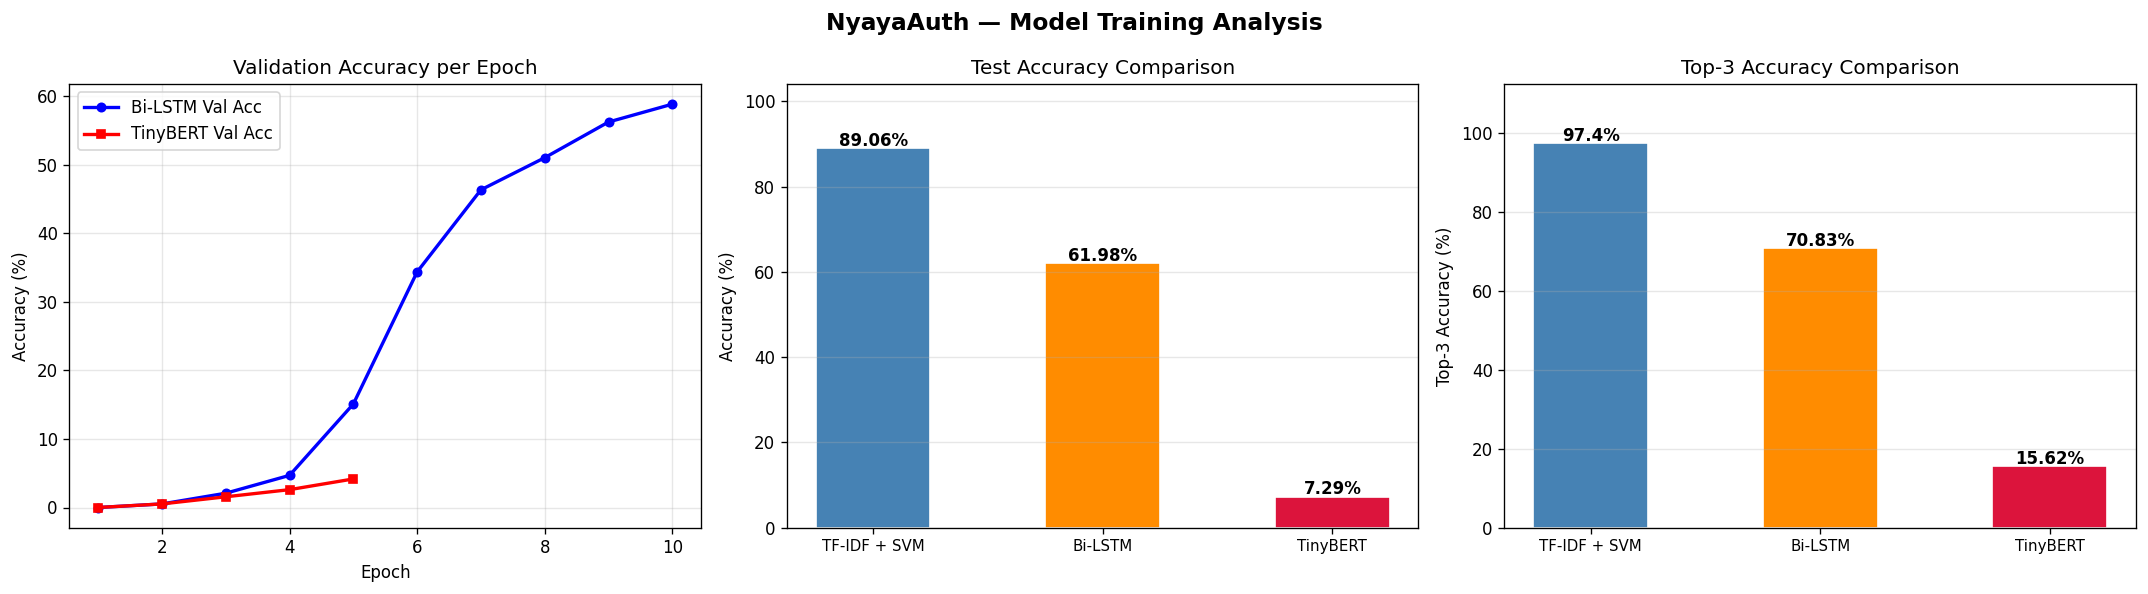

✅ Plot saved → /content/drive/MyDrive/NyayaAuth/logs/model_comparison_plot.png

📊 Models plotted: ['TF-IDF + SVM', 'Bi-LSTM', 'TinyBERT']


In [16]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
matplotlib.rcParams['figure.dpi'] = 120

# ── Safety checks before plotting ────────────────────────
# Build history safely — use whatever is available
plot_histories = {}
if 'lstm_history' in dir() and len(lstm_history.get("val_acc", [])) > 0:
    plot_histories["Bi-LSTM"] = lstm_history["val_acc"]
if 'bert_history' in dir() and len(bert_history.get("val_acc", [])) > 0:
    plot_histories["TinyBERT"] = bert_history["val_acc"]

# Build RESULTS safely — only plot models that actually finished
available_models = [m for m in ["TF-IDF + SVM", "Bi-LSTM", "TinyBERT"]
                    if m in RESULTS]

if len(available_models) == 0:
    print("❌ No models in RESULTS yet. Train at least one model first.")
else:
    COLOR_MAP = {
        "TF-IDF + SVM": "steelblue",
        "Bi-LSTM"     : "darkorange",
        "TinyBERT"    : "crimson"
    }

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("NyayaAuth — Model Training Analysis",
                 fontsize=14, fontweight='bold')

    # ── Plot 1: Training curves (only for models that have history) ──
    ax = axes[0]
    line_styles = {"Bi-LSTM": ('b-o', 2, 5), "TinyBERT": ('r-s', 2, 5)}

    if len(plot_histories) == 0:
        ax.text(0.5, 0.5, "No training history\navailable",
                ha='center', va='center', transform=ax.transAxes,
                fontsize=12, color='gray')
    else:
        for model_name, val_accs in plot_histories.items():
            style, lw, ms = line_styles.get(model_name, ('g-^', 2, 5))
            epochs = range(1, len(val_accs) + 1)
            ax.plot(epochs,
                    [v * 100 for v in val_accs],
                    style,
                    label=f"{model_name} Val Acc",
                    linewidth=lw,
                    markersize=ms)

    ax.set_title("Validation Accuracy per Epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    if len(plot_histories) > 0:
        ax.legend()
    ax.grid(True, alpha=0.3)

    # ── Plot 2: Test accuracy bar chart ──────────────────────────────
    ax = axes[1]
    accs   = [RESULTS[m]["accuracy"] for m in available_models]
    colors = [COLOR_MAP[m] for m in available_models]
    bars   = ax.bar(available_models, accs,
                    color=colors, edgecolor="white", width=0.5)

    ax.set_title("Test Accuracy Comparison")
    ax.set_ylabel("Accuracy (%)")
    max_acc = max(accs) if accs else 100
    ax.set_ylim([0, min(max_acc + 15, 110)])

    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{acc}%",
                ha='center', fontweight='bold', fontsize=10)

    ax.tick_params(axis='x', labelsize=9)
    ax.grid(True, axis='y', alpha=0.3)

    # ── Plot 3: Top-3 accuracy bar chart ─────────────────────────────
    ax = axes[2]
    # Use top3_accuracy if available, else fall back to accuracy
    top3   = [RESULTS[m].get("top3_accuracy", RESULTS[m]["accuracy"])
              for m in available_models]
    bars2  = ax.bar(available_models, top3,
                    color=colors, edgecolor="white", width=0.5)

    ax.set_title("Top-3 Accuracy Comparison")
    ax.set_ylabel("Top-3 Accuracy (%)")
    max_top3 = max(top3) if top3 else 100
    ax.set_ylim([0, min(max_top3 + 15, 115)])

    for bar, t3 in zip(bars2, top3):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{t3}%",
                ha='center', fontweight='bold', fontsize=10)

    ax.tick_params(axis='x', labelsize=9)
    ax.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()

    import os
    os.makedirs(f"{PROJECT_DIR}/logs", exist_ok=True)
    plot_path = f"{PROJECT_DIR}/logs/model_comparison_plot.png"
    plt.savefig(plot_path, bbox_inches="tight")
    plt.show()
    print(f"✅ Plot saved → {plot_path}")
    print(f"\n📊 Models plotted: {available_models}")

## Cell 13 — Final checklist

In [17]:
saved_files = {
    f"{MODEL_DIR}/tfidf/tfidf_svm_model.pkl"    : "TF-IDF + SVM model",
    f"{MODEL_DIR}/lstm/bilstm_best.pt"           : "Bi-LSTM best weights",
    f"{MODEL_DIR}/lstm/vocab.pkl"                : "LSTM vocabulary",
    f"{MODEL_DIR}/tinybert/tinybert_best.pt"     : "TinyBERT best weights",
    f"{MODEL_DIR}/tinybert/tokenizer/tokenizer_config.json": "TinyBERT tokenizer",
    f"{PROJECT_DIR}/logs/model_comparison.csv"   : "Results CSV",
    f"{PROJECT_DIR}/logs/model_comparison_plot.png": "Results plot",
}

print("=" * 65)
print("  NyayaAuth — Step 3 Complete — Final Checklist")
print("=" * 65)

all_ok = True
for fpath, desc in saved_files.items():
    exists = os.path.exists(fpath)
    size   = os.path.getsize(fpath)/1024 if exists else 0
    icon   = "✅" if exists else "❌"
    print(f"  {icon}  {desc:35s}  {size:8.1f} KB")
    if not exists:
        all_ok = False

print(f"\n{'='*65}")
print(f"  📊 Final Results Summary")
print(f"{'='*65}")
for model, res in RESULTS.items():
    print(f"  {model:15s} → Acc: {res['accuracy']:6.2f}%  "
          f"F1: {res['macro_f1']:6.2f}%  "
          f"Top-3: {res['top3_accuracy']:6.2f}%  "
          f"Speed: {res['infer_ms']:.2f}ms")

print(f"{'='*65}")
if all_ok:
    print("\n🚀 Step 3 complete! All models trained and saved to Google Drive.")
    print("   Next → Step 4: Build the FastAPI Prediction Server")
else:
    print("\n⚠️  Some files missing. Re-run the cells marked ❌")

  NyayaAuth — Step 3 Complete — Final Checklist
  ✅  TF-IDF + SVM model                   117847.2 KB
  ✅  Bi-LSTM best weights                  10930.9 KB
  ✅  LSTM vocabulary                          23.3 KB
  ✅  TinyBERT best weights                 56553.7 KB
  ✅  TinyBERT tokenizer                        1.2 KB
  ✅  Results CSV                               0.2 KB
  ✅  Results plot                             81.5 KB

  📊 Final Results Summary
  TF-IDF + SVM    → Acc:  89.06%  F1:  82.92%  Top-3:  97.40%  Speed: 0.55ms
  Bi-LSTM         → Acc:  61.98%  F1:  49.73%  Top-3:  70.83%  Speed: 0.57ms
  TinyBERT        → Acc:   7.29%  F1:   4.43%  Top-3:  15.62%  Speed: 1.35ms

🚀 Step 3 complete! All models trained and saved to Google Drive.
   Next → Step 4: Build the FastAPI Prediction Server
